# Predicting Wine quality using Gradient Boosting Classifier

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix,accuracy_score,classification_report
from imblearn.over_sampling import SMOTE
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('winequality-red.csv',sep=';')

In [3]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [8]:
df['label'] = df.quality.apply(lambda x: 1 if x>=7 else 0)
df = df.drop('quality',axis=1)

In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,label
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0


In [12]:
x = df.drop('label',axis=1)
y = df['label']
x_train,x_test,y_train,y_test = train_test_split(
    x,y,random_state=42,test_size=0.2,stratify=y
)

In [13]:
smote = SMOTE(random_state=42)
x_train_res,y_train_res = smote.fit_resample(x_train,y_train)

In [14]:
print("After SMOTE:\n",np.bincount(y_train_res))

After SMOTE:
 [1105 1105]


In [18]:
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

In [19]:
gb_model.fit(x_train_res,y_train_res)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [21]:
y_pred = gb_model.predict(x_test)

In [23]:
print("Classification Report:\n",classification_report(y_test,y_pred))

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.91      0.93       277
           1       0.54      0.70      0.61        43

    accuracy                           0.88       320
   macro avg       0.74      0.80      0.77       320
weighted avg       0.89      0.88      0.88       320



Confusion Matrix


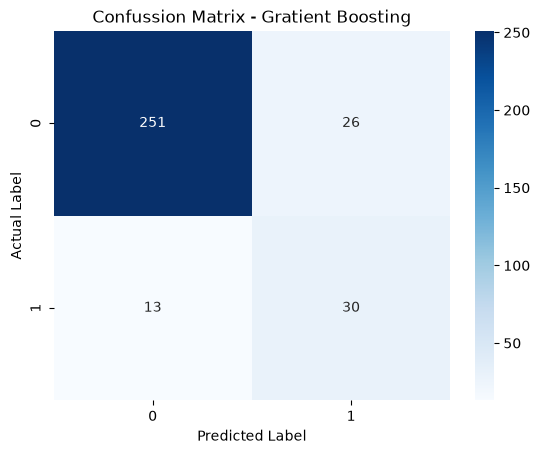

In [22]:
print("Confusion Matrix")
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title("Confussion Matrix - Gratient Boosting")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

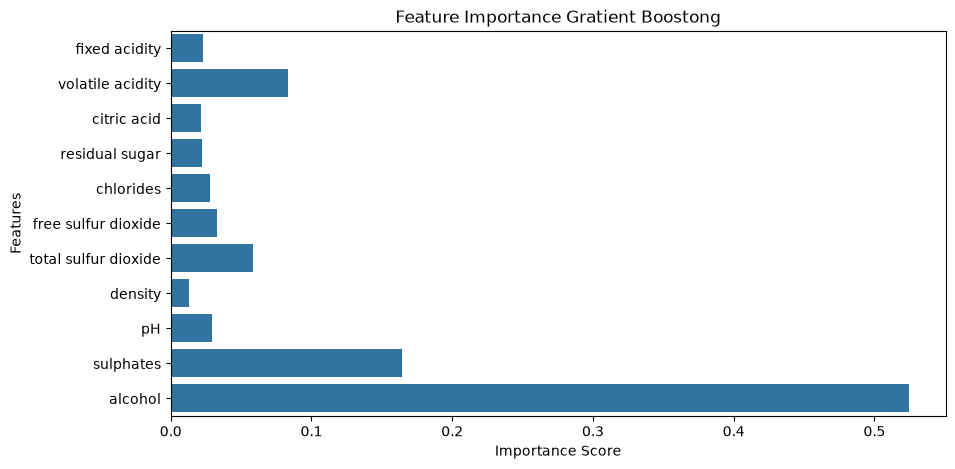

In [24]:
importances = gb_model.feature_importances_
features = x.columns

plt.figure(figsize=(10,5))
sns.barplot(x=importances,y=features)
plt.title("Feature Importance Gratient Boostong")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()